# Task 1: Model Training and Optimization Pipeline
Use this notebook to perform your data preprocessing, hyperparameter tuning via Cross-Validation, and final evaluation on the test set.

In [22]:
import pandas as pd
import numpy as np
import pickle
import time
import optuna
import trackio
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Add any other imports you need here
from sklearn.model_selection import KFold
from scipy.stats import randint as sp_randint
import os
import joblib
import warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 1. Data Loading & Preprocessing
Load `train.csv` and `test.csv`. Convert string categorical variables to numeric.
**Required:** Save your label encoders/mappings because your Streamlit UI will need them later to prepare user inputs for inference!

In [23]:
train_df = pd.read_csv('Dataset/train.csv')
test_df = pd.read_csv('Dataset/test.csv')

# TODO: Implement your preprocessing here (use LabelEncoder or manual dictionaries)
# Ensure you keep all necessary features that will be shown on the UI dashboard.
train_df = train_df[train_df['BHK'] > 0]
test_df  = test_df[test_df['BHK'] > 0]

categ_cols = ["city", "location", "Status", "property_type"]
encoders = {}

for col in categ_cols:
    le = LabelEncoder()
    # Fit on UNION of train+test so unseen labels in test don't crash
    combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))
    encoders[col] = le

train_df["isNegotiable"] = train_df["isNegotiable"].astype(int)
test_df["isNegotiable"] = test_df["isNegotiable"].astype(int)

# Save encoders: Streamlit uses le.classes_ for dropdowns
with open("models/label_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

# TODO: Separate predictors (X) and target (y: 'price')
target = "price"
features = [c for c in train_df.columns if c != target]
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Save feature column names for app.py
with open("models/feature_names.pkl", "wb") as f:
    pickle.dump(features, f)

print(f"\nFeatures ({len(features)}): {features}")
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")


Features (14): ['location', 'city', 'latitude', 'longitude', 'numBathrooms', 'numBalconies', 'isNegotiable', 'SecurityDeposit', 'Status', 'Size_ft²', 'BHK', 'rooms_num', 'property_type', 'verification_days']
X_train shape: (10789, 14) | X_test shape: (2687, 14)


In [24]:
print(train_df[categ_cols].head(5))
print("\nSample encoded values:")
for col in categ_cols:
    print(f" {col}: {encoders[col].classes_[:5]}")
print("\ny_train sample:", y_train[:5])

   city  location  Status  property_type
0     2       597       2              0
1     2       597       2              0
2     2         6       1              0
4     0       219       2              0
5     0       131       0              1

Sample encoded values:
 city: ['Delhi' 'Hisar' 'Mumbai' 'Pune']
 location: [' Kharadi' 'AGCR Enclave' 'Aarya Chanakya Nagar'
 'Abul Fazal Enclave Jamia Nagar' 'Agalambe']
 Status: ['Furnished' 'Semi-Furnished' 'Unfurnished']
 property_type: ['Apartment' 'Independent Floor' 'Independent House' 'Villa' 'penthouse']

y_train sample: 0     27000
1     13500
2     20000
4     24500
5    120000
Name: price, dtype: int64


## 2. Hyperparameter Tuning using Cross-Validation

**Strict Search Space:**
- `n_estimators`: 50 to 200
- `max_depth`: 10 to 30
- `min_samples_split`: 2 to 10

Implement Grid Search, Random Search, and Bayesian Optimization (using Optuna). Evaluate each using 5-fold cross-validation on `train_df`.

In [26]:
rf = RandomForestRegressor(random_state=42)

# TODO: Initialize trackio project/experiment here
trackio.init(project= "UrbanNest_RentPrediction", name="GridSearch", resume="never")
# TODO: 1. Grid Search Implementation
# Use trackio to log the method name, time taken, number of iterations, and best cross-validation score
cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid_curve  = []
rand_curve  = []
bayes_curve = []

grid_params = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [10, 15, 20, 25, 30],
    "min_samples_split": [2, 5, 8],
}

t0 = time.time()

grid_search = GridSearchCV(
    estimator  = rf,
    param_grid = grid_params,
    cv         = cv,
    scoring    = "neg_mean_absolute_error",
    n_jobs     = -1,
    verbose    = 0,
)

grid_search.fit(X_train, y_train)
grid_time = time.time() - t0

grid_all_maes = -grid_search.cv_results_["mean_test_score"]
grid_curve    = np.minimum.accumulate(grid_all_maes).tolist()

grid_best_mae    = -grid_search.best_score_
grid_best_params = grid_search.best_params_

trackio.log({
    "method": "GridSearch",
    "best_cv_mae": float(round(grid_best_mae, 4)),
    "time_seconds": float(round(grid_time, 2)),
    "num_iterations": int(60),
    "n_estimators": int(grid_best_params["n_estimators"]),
    "max_depth": int(grid_best_params["max_depth"]),
    "min_samples_split": int(grid_best_params["min_samples_split"]),
})
trackio.finish()

print(f"Grid Search done in {grid_time:.1f}s | Best CV MAE: {grid_best_mae:.4f}")
print(f"Best params: {grid_best_params}")

# TODO: 2. Random Search Implementation
# Use trackio to log the method name, time taken, number of iterations, and best cross-validation score
trackio.init(project="UrbanNest_RentPrediction", name="RandomSearch", resume="never")

rand_params = {
    "n_estimators":      sp_randint(50, 201),
    "max_depth":         sp_randint(10, 31),
    "min_samples_split": sp_randint(2,  11),
}
t0 = time.time()

rand_search = RandomizedSearchCV(
    estimator = rf,
    param_distributions = rand_params,
    n_iter = 60,
    cv = cv,
    scoring = "neg_mean_absolute_error",
    n_jobs = -1,
    random_state = 42,
    verbose = 0,
)
rand_search.fit(X_train, y_train)
rand_time = time.time() - t0

rand_all_maes = -rand_search.cv_results_["mean_test_score"]
rand_curve    = np.minimum.accumulate(rand_all_maes).tolist()

rand_best_mae    = -rand_search.best_score_
rand_best_params = rand_search.best_params_

trackio.log({
    "method": "RandomSearch",
    "best_cv_mae": float(round(rand_best_mae, 4)),
    "time_seconds": float(round(rand_time, 2)),
    "num_iterations": int(60),
    "n_estimators": int(rand_best_params["n_estimators"]),
    "max_depth": int(rand_best_params["max_depth"]),
    "min_samples_split": int(rand_best_params["min_samples_split"]),
})
trackio.finish()

print(f"Random Search done in {rand_time:.1f}s | Best CV MAE: {rand_best_mae:.4f}")
print(f"Best params: {rand_best_params}")

# TODO: 3. Bayesian Optimization (Optuna) Implementation
# Use trackio to log the method name, time taken, number of iterations, and best cross-validation score
trackio.init(project="UrbanNest_RentPrediction", name="BayesianOptimization_Optuna", resume="never")

bayes_trial_maes = []

def optuna_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators",      50, 200),
        "max_depth":         trial.suggest_int("max_depth",         10,  30),
        "min_samples_split": trial.suggest_int("min_samples_split",  2,  10),
        "random_state":      42,
        "n_jobs":            -1,
    }
    model  = RandomForestRegressor(**params)
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)
    mae = -np.mean(scores)
    bayes_trial_maes.append(mae)
    return mae

t0 = time.time()

study = optuna.create_study(
    direction  = "minimize",
    study_name = "UrbanNest_Byesian",
    sampler    = optuna.samplers.TPESampler(seed=42),
)
study.optimize(optuna_objective, n_trials=60, show_progress_bar=False)
bayes_time = time.time() - t0

bayes_curve = np.minimum.accumulate(bayes_trial_maes).tolist()

bayes_best_mae    = study.best_value
bayes_best_params = study.best_params

trackio.log({
    "method": "BayesianOptimization",
    "best_cv_mae": float(round(bayes_best_mae, 4)),
    "time_seconds": float(round(bayes_time, 2)),
    "num_iterations": int(60),
    "n_estimators": int(bayes_best_params["n_estimators"]),
    "max_depth": int(bayes_best_params["max_depth"]),
    "min_samples_split": int(bayes_best_params["min_samples_split"]),
})
trackio.finish()

print(f"Bayesian Optimization done in {bayes_time:.1f}s | Best CV MAE: {bayes_best_mae:.4f}")
print(f"Best params: {bayes_best_params}")

* Run finished. Uploading logs to Trackio (please wait...)
* Created new run: GridSearch
* Run finished. Uploading logs to Trackio (please wait...)
Grid Search done in 568.5s | Best CV MAE: 13978.8483
Best params: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}
* Created new run: RandomSearch
* Run finished. Uploading logs to Trackio (please wait...)
Random Search done in 145.5s | Best CV MAE: 14014.1515
Best params: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 107}
* Created new run: BayesianOptimization_Optuna
* Run finished. Uploading logs to Trackio (please wait...)
Bayesian Optimization done in 202.5s | Best CV MAE: 13968.4218
Best params: {'n_estimators': 186, 'max_depth': 28, 'min_samples_split': 2}


In [ ]:
print("Grid errors (last 5):", grid_curve[-5:])
print("Random errors (last 5):", rand_curve[-5:])
print("Optuna errors (last 5):", bayes_curve[-5:])
print("Lengths:", len(grid_curve), len(rand_curve), len(bayes_curve))

Grid errors (last 5): [13978.848311950826, 13978.848311950826, 13978.848311950826, 13978.848311950826, 13978.848311950826]
Random errors (last 5): [14014.151521977095, 14014.151521977095, 14014.151521977095, 14014.151521977095, 14014.151521977095]
Optuna errors (last 5): [13968.42181519516, 13968.42181519516, 13968.42181519516, 13968.42181519516, 13968.42181519516]
Lengths: 60 60 60


## 3. Evaluation & Plots
Plot the compute trials (iterations) vs. cross-validation error, and plot the hyperparameter space to visualize how the Bayesian method explored the space.

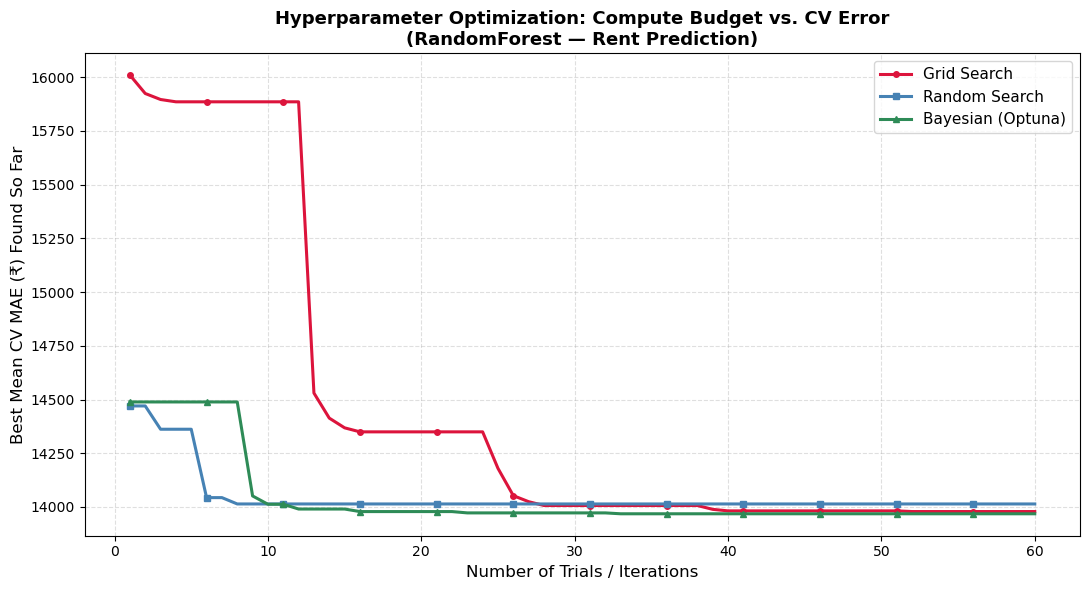

Saved: plots/trials_vs_error.png
Plotly/kaleido save failed (
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido
), using matplotlib fallback.


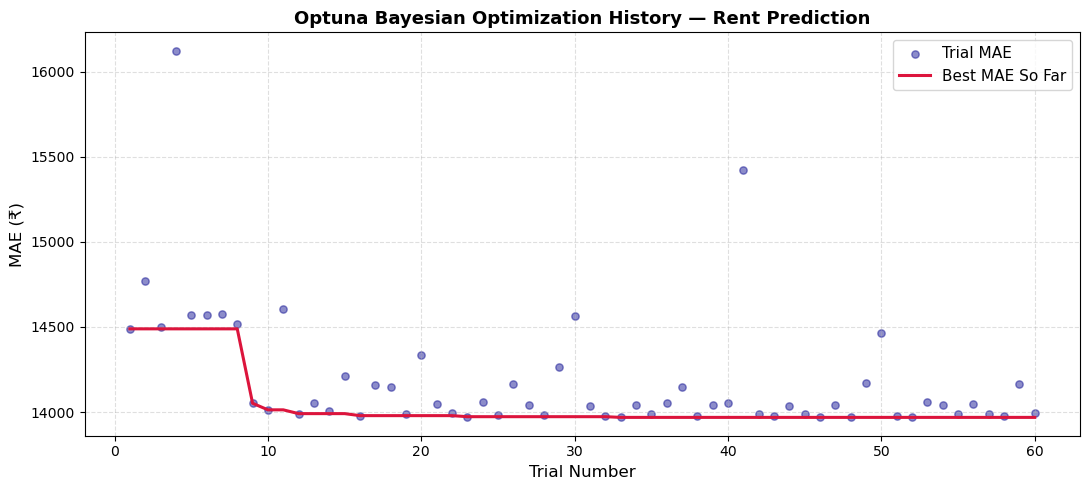

Saved: plots/optuna_hyperparameter_space.png (matplotlib fallback)


In [ ]:
# TODO: Generate and save trials_vs_error.png
# X-axis: Number of iterations
# Y-axis: Best CV error found so far
# Overlay Grid, Random, and Bayesian methods on the same plot.

plt.figure(figsize=(11, 6))
plt.plot(range(1, 61), grid_curve, label="Grid Search", color="crimson", linewidth=2.2, marker="o", markevery=5, markersize=4)
plt.plot(range(1, 61), rand_curve, label="Random Search", color="steelblue", linewidth=2.2, marker="s", markevery=5, markersize=4)
plt.plot(range(1, 61), bayes_curve, label="Bayesian (Optuna)", color="seagreen", linewidth=2.2, marker="^", markevery=5, markersize=4)
plt.xlabel("Number of Trials / Iterations", fontsize=12)
plt.ylabel("Best Mean CV MAE (₹) Found So Far", fontsize=12)
plt.title("Hyperparameter Optimization: Compute Budget vs. CV Error\n(RandomForest — Rent Prediction)", fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("plots/trials_vs_error.png", dpi=150)
plt.show()
print("Saved: plots/trials_vs_error.png")

# TODO: Generate and save optuna_hyperparameter_space.png

try:
    fig = optuna.visualization.plot_optimization_history(study)
    fig.update_layout(title="Optuna Bayesian Optimization History — Rent Prediction")
    fig.write_image("plots/optuna_hyperparameter_space.png", width=900, height=500)
    print("Saved: plots/optuna_hyperparameter_space.png (plotly)")

except Exception as e:
    print(f"Plotly/kaleido save failed ({e}), using matplotlib fallback.")
    trial_nums = [t.number + 1 for t in study.trials]
    trial_vals = [t.value      for t in study.trials]
    plt.figure(figsize=(11, 5))
    plt.scatter(trial_nums, trial_vals, alpha=0.45, s=28,
                color="darkblue", label="Trial MAE")
    plt.plot(trial_nums, np.minimum.accumulate(trial_vals),
             color="crimson", linewidth=2.2, label="Best MAE So Far")
    plt.xlabel("Trial Number", fontsize=12)
    plt.ylabel("MAE (₹)",      fontsize=12)
    plt.title("Optuna Bayesian Optimization History — Rent Prediction", fontsize=13, fontweight="bold")
    plt.legend(fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig("plots/optuna_hyperparameter_space.png", dpi=150)
    plt.show()
    print("Saved: plots/optuna_hyperparameter_space.png (matplotlib fallback)")

## 4. Final Testing & Model Saving
Report the best hyperparameters found, train your overall best model on the entire `train.csv`, evaluate on `test.csv`, and save the model file.

In [27]:
# TODO: Print the best hyperparameters found by all 3 methods
print("="*60)
print("BEST HYPERPARAMETERS FOUND BY EACH METHOD")
print("="*60)
print(f"Grid Search        : {grid_best_params}  | CV MAE: {grid_best_mae:.4f}")
print(f"Random Search      : {rand_best_params}  | CV MAE: {rand_best_mae:.4f}")
print(f"Bayesian (Optuna)  : {bayes_best_params} | CV MAE: {bayes_best_mae:.4f}")
print("="*60)

# Select the overall best method — lowest CV MAE wins
candidates = {
    "Grid Search":          (grid_best_mae,  grid_best_params),
    "Random Search":        (rand_best_mae,  rand_best_params),
    "Bayesian Optimization":(bayes_best_mae, bayes_best_params),
}
best_name   = min(candidates, key=lambda k: candidates[k][0])
best_params = candidates[best_name][1]

print(f"\nWinner: {best_name}")
print(f"Params: {best_params}")

# TODO: Train the best model found on the full X_train
# Retrain on 100% of training data — during CV each fold only used 80%
best_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)
print("\nBest model retrained on full X_train")

# TODO: Evaluate the model on X_test (Report MAE)
y_pred   = best_model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred)

print("\n" + "="*60)
print("FINAL EVALUATION ON test.csv")
print("="*60)
print(f"Winning method : {best_name}")
print(f"Hyperparameters : {best_params}")
print(f"Test MAE (₹) : {test_mae:,.2f}")
print("="*60)

# TODO: Save best_model.pkl and any necessary encoders to the models/ folder
# joblib for the model : better than pickle for large numpy arrays inside RF
# pickle for encoders and feature names : small objects, pickle is fine
joblib.dump(best_model, "models/best_rf_model.pkl")
print("\nSaved (joblib) : models/best_rf_model.pkl")

with open("models/label_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)
print("Saved (pickle) : models/label_encoders.pkl")

with open("models/feature_names.pkl", "wb") as f:
    pickle.dump(features, f)
print("Saved (pickle) : models/feature_names.pkl")


BEST HYPERPARAMETERS FOUND BY EACH METHOD
Grid Search        : {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}  | CV MAE: 13978.8483
Random Search      : {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 107}  | CV MAE: 14014.1515
Bayesian (Optuna)  : {'n_estimators': 186, 'max_depth': 28, 'min_samples_split': 2} | CV MAE: 13968.4218

Winner: Bayesian Optimization
Params: {'n_estimators': 186, 'max_depth': 28, 'min_samples_split': 2}

Best model retrained on full X_train

FINAL EVALUATION ON test.csv
Winning method : Bayesian Optimization
Hyperparameters : {'n_estimators': 186, 'max_depth': 28, 'min_samples_split': 2}
Test MAE (₹) : 12,870.67

Saved (joblib) : models/best_rf_model.pkl
Saved (pickle) : models/label_encoders.pkl
Saved (pickle) : models/feature_names.pkl
